In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías y de `listings_train.csv`/`listings_test.csv`, el split guardado por `03_model_baseline.ipynb` (mismo `random_state=42`, para que los resultados sean comparables entre notebooks).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/mallorca/listings_train.csv")
test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/mallorca/listings_test.csv")
train_df.shape, test_df.shape

((8835, 125), (2209, 125))

## 2. ¿Qué modelos vamos a probar?

En el baseline, la regresión lineal ya llegó a R²=0,39 pese al mercado mucho más disperso y heterogéneo de Mallorca (villas + pisos, 53 municipios). Con eso en mente, se prueban los mismos cuatro tipos de modelo que en las otras cinco ciudades:

- **Ridge**: versión regularizada de la regresión lineal del baseline. Con la multicolinealidad severa detectada en `03_model_baseline.ipynb` (número de condición 2,4·10¹⁹, la más alta de las seis ciudades), es el candidato más obvio para ver si la regularización ayuda antes de pasar a algo no lineal.
- **Random Forest**: ensemble por *bagging* de árboles de decisión. Robusto, apenas necesita ajuste, no le afecta la escala ni la multicolinealidad. No admite `NaN`.
- **Extra Trees**: variante de Random Forest con aleatoriedad extra al elegir los cortes de cada árbol. Tampoco admite `NaN`.
- **Hist Gradient Boosting**: ensemble por *boosting* basado en histogramas, el sustituto de `scikit-learn` más parecido a XGBoost/LightGBM (que no se pudieron usar por el problema de `libomp`, igual que en las otras ciudades). Admite `NaN` nativamente.

Los cuatro se entrenan dentro de un `Pipeline`. Para Ridge/Random Forest/Extra Trees el pipeline incluye un paso de imputación (y de escalado, solo para Ridge); para Hist Gradient Boosting no se imputa nada, para conservar la información de "sin reviews todavía" que aporta el propio `NaN`.

## 3. Preparación de X e y

Mismos identificadores, objetivo y columnas de fuga que en `03_model_baseline.ipynb`. A diferencia del baseline, aquí no se imputa nada todavía: eso queda dentro de cada `Pipeline`.

### 3.1 Identificadores, objetivo y columnas de fuga

In [3]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
leakage_cols = ["price_log", "price_per_accommodate", "price_per_min_night"]
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col] + leakage_cols]

len(feature_cols)

118

### 3.2 X e y

`train_df`/`test_df` ya son el split guardado por el baseline, así que aquí no hace falta volver a dividir nada.

In [4]:
X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

X_train.shape, X_test.shape

((8835, 118), (2209, 118))

### 3.3 Booleanas a 0/1

In [5]:
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

len(bool_cols)

87

### 3.4 Nulos: sin tratar todavía

`review_scores_rating`, `listing_age_days` y `days_since_last_review` se quedan con sus `NaN` tal cual; cada `Pipeline` de la sección 4 decide si los imputa o los deja pasar al modelo.

In [6]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

review_scores_rating      1490
listing_age_days          1490
days_since_last_review    1490
dtype: int64

## 4. Pipelines

Un `Pipeline` por modelo, con el preprocesado que necesita cada uno.

### 4.1 Objetivo: `log1p(price)`

Mismo criterio que en el baseline: se entrena sobre `log1p(price)`, no sobre `price` directamente.

In [7]:
y_train_log = np.log1p(y_train)

### 4.2 Un `Pipeline` por modelo

In [8]:
pipelines = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

list(pipelines.keys())

['Ridge', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting']

Con hiperparámetros por defecto en los cuatro por ahora: el ajuste fino es la sección 6.

## 5. Entrenamiento y comparación entre modelos

Los cuatro pipelines evaluados por validación cruzada sobre el train (sin tocar el test todavía).

### 5.1 Función `evaluate` y validación cruzada manual

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

In [10]:
from sklearn.model_selection import KFold

def cv_evaluate(pipeline, X, y_log, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        pipeline.fit(X_tr, y_tr_log)
        pred = np.expm1(pipeline.predict(X_val))
        y_val = np.expm1(y_val_log)
        scores.append(evaluate(y_val, pred, name))
    return pd.DataFrame(scores).drop(columns="modelo").mean()

### 5.2 Comparar los cuatro con 5-fold CV

In [11]:
cv_rows = []
for name, pipe in pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    cv_rows.append(scores)

cv_results = pd.DataFrame(cv_rows).set_index("modelo")
cv_results.round(2)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

,RMSE,MAE,R2,MAPE
modelo,,,,
Ridge,557.73,252.09,0.48,40.51
Random Forest,481.05,209.08,0.61,33.31
Extra Trees,475.58,208.16,0.62,32.98
Hist Gradient Boosting,465.96,202.18,0.64,32.25


### 5.3 Interpretación

Salto claro de lineal a no lineal, pero con un matiz propio de Mallorca: **Ridge (R²=0,48) ya mejora bastante sobre la regresión lineal sin regularizar del baseline (R²=0,39)** — la regularización amortigua parte del daño causado por la multicolinealidad severa vista en `03_model_baseline.ipynb` (número de condición 2,4·10¹⁹). Aun así, los tres modelos de árboles siguen por delante: Random Forest 0,61, Extra Trees 0,62, Hist Gradient Boosting 0,64 (el mejor con hiperparámetros por defecto). Coherente con el baseline: `accommodates` por sí solo apenas explicaba varianza (R²=0,10 en el baseline por `accommodates`), así que queda bastante terreno no lineal (tipo de propiedad, la relación en "U" entre `distance_to_center_km` y el precio...) que solo un modelo de árboles puede aprovechar.

Como en las otras ciudades, esta comparación no decide nada: los tres modelos de árboles se afinan igualmente en la sección 6, no solo el que gane aquí por poco.

## 6. Ajuste de hiperparámetros

Se afinan Random Forest, Extra Trees y Hist Gradient Boosting con `RandomizedSearchCV` y validación cruzada.

`RandomizedSearchCV` con 15 combinaciones y 3 folds por modelo (45 entrenamientos cada uno), sobre `y_train_log` con `scoring="r2"`.

### 6.1 Random Forest

In [12]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.7479578201405133


### 6.2 Extra Trees

In [13]:
et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

et_search = RandomizedSearchCV(
    pipelines["Extra Trees"], et_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
et_search.fit(X_train, y_train_log)

print(et_search.best_params_)
print(et_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.7476551602510325


### 6.3 Hist Gradient Boosting

In [14]:
hgb_param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__l2_regularization": [0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    pipelines["Hist Gradient Boosting"], hgb_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train_log)

print(hgb_search.best_params_)
print(hgb_search.best_score_)

{'model__max_leaf_nodes': 63, 'model__max_iter': 300, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
0.7643275291101667


### 6.4 Resumen

Los tres suben de R²≈0,61-0,64 (sin afinar, en euros) a **R²≈0,75-0,76 en escala logarítmica** con los mejores hiperparámetros (Random Forest 0,748, Extra Trees 0,748, Hist Gradient Boosting 0,764 — el mejor). Random Forest y Extra Trees convergen exactamente en la misma combinación de hiperparámetros (`n_estimators=500, min_samples_split=2, min_samples_leaf=1, max_features=0.5, max_depth=None`), señal de que en Mallorca la aleatoriedad extra de Extra Trees no aporta ninguna ventaja sobre Random Forest. Ojo: este número está en la escala de `log1p(price)`, no es directamente comparable con la tabla en euros de la sección 5 — la comparación justa en euros se hace en la sección 7.

In [15]:
from sklearn.base import clone

tuned_pipelines = {
    "Random Forest (tuned)": clone(rf_search.best_estimator_),
    "Extra Trees (tuned)": clone(et_search.best_estimator_),
    "Hist Gradient Boosting (tuned)": clone(hgb_search.best_estimator_),
}

tuned_rows = []
for name, pipe in tuned_pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    tuned_rows.append(scores)

tuned_results = pd.DataFrame(tuned_rows).set_index("modelo")
tuned_results.round(2)

,RMSE,MAE,R2,MAPE
modelo,,,,
Random Forest (tuned),486.52,207.47,0.60,32.76
Extra Trees (tuned),486.73,207.10,0.60,32.50
Hist Gradient Boosting (tuned),457.98,199.21,0.65,31.59


## 7. Elegir el modelo final

Los tres modelos ya afinados, comparados entre sí (seguimos sin tocar el test).

### 7.1 Comparar en euros con los mejores hiperparámetros

In [16]:
final_model_name = "Hist Gradient Boosting"
final_pipeline = hgb_search.best_estimator_
final_pipeline

Pipeline(steps=[('model',
                 HistGradientBoostingRegressor(l2_regularization=0,
                                               learning_rate=0.05, max_depth=10,
                                               max_iter=300, max_leaf_nodes=63,
                                               random_state=42))])

### 7.2 Decisión

**Hist Gradient Boosting gana claramente en las cuatro métricas**: RMSE (457,98), MAE (199,21), R² (0,65) y MAPE (31,59%), por delante de Extra Trees (486,73 / 207,10 / 0,60 / 32,50) y Random Forest (486,52 / 207,47 / 0,60 / 32,76). Se decide por **Hist Gradient Boosting**, igual que en las otras cinco ciudades.

## 8. Evaluación en test

El modelo elegido en la sección 7, entrenado sobre todo el train y evaluado una única vez sobre el test.

### 8.1 Evaluar en test, por primera y única vez

In [17]:
pred_final = np.expm1(final_pipeline.predict(X_test))

evaluate(y_test, pred_final, "Hist Gradient Boosting (final)")

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': np.float64(605.9437508368522),
 'MAE': 212.12461842440328,
 'R2': 0.5429289937482078,
 'MAPE': np.float64(30.616312888325258)}

### 8.2 Train vs. test: ¿hay sobreajuste?

In [18]:
pred_train = np.expm1(final_pipeline.predict(X_train))

pd.DataFrame([
    evaluate(y_train, pred_train, "Train"),
    evaluate(y_test, pred_final, "Test"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Train,266.153770,112.810408,0.882452,17.320726
Test,605.943751,212.124618,0.542929,30.616313


Brecha real y notable: el modelo acierta mucho más de cerca en train (MAE 112,8€, R²=0,88) que en test (MAE 212,1€, R²=0,54). Parte se explica por una causa identificable, no por un fallo del pipeline: `y_train` tiene una asimetría de 5,75 (máximo 13.942€) y `y_test` de 9,05 (máximo 22.260€) — **el test quedó, por puro azar del split, con la villa más cara de todo el dataset (Villa Carlini, 22.260€) y una cola relativa bastante más pronunciada que el train**. Como RMSE y R² penalizan los errores grandes al cuadrado, un puñado de villas extremas en el test pesa desproporcionadamente. Aun así, la brecha en Mallorca es más grande que en Málaga (que tenía un patrón similar pero más moderado): con 118 features sobre solo 8.835 filas de train, y la multicolinealidad más severa de las seis ciudades ya documentada en `03_model_baseline.ipynb`, hay también margen para algo de sobreajuste genuino del modelo de árboles, no solo varianza de split. Un matiz importante a llevar a `05_model_evaluation.ipynb`: conviene revisar el error específicamente en los anuncios de precio muy alto.

## 9. Comparación con el baseline

El resultado de la sección 8 frente al listón de `03_model_baseline.ipynb` (regresión lineal: R²=0,39, MAE≈268€).

In [19]:
{
    "Regresión lineal (baseline)": {"RMSE": 699.54, "MAE": 267.99, "R2": 0.39, "MAPE": 39.64},
    "Hist Gradient Boosting (final)": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
}

{'Regresión lineal (baseline)': {'RMSE': 699.54,
  'MAE': 267.99,
  'R2': 0.39,
  'MAPE': 39.64},
 'Hist Gradient Boosting (final)': {'modelo': 'Hist Gradient Boosting (final)',
  'RMSE': np.float64(605.9437508368522),
  'MAE': 212.12461842440328,
  'R2': 0.5429289937482078,
  'MAPE': np.float64(30.616312888325258)}}

Mejora clara en las cuatro métricas: **RMSE de 699,5€ a 605,9€, MAE de 268,0€ a 212,1€, R² de 0,39 a 0,54, MAPE de 39,6% a 30,6%**. La mejora relativa en MAE (-20,8%) es sólida, aunque no cierra la distancia con las ciudades de geografía más simple: el mercado de Mallorca (villas + pisos, 53 municipios, precios de 28€ a 22.260€) sigue siendo, con diferencia, el más difícil de explicar en términos absolutos de las seis ciudades del proyecto.

## 10. Importancia de variables

Igual que en las otras ciudades: `HistGradientBoostingRegressor` no tiene `feature_importances_`, así que se usa **permutation importance**.

### 10.1 Calcular la importancia

Se calcula sobre el test, para medir qué variables son importantes de cara a generalizar.

In [20]:
from sklearn.inspection import permutation_importance

y_test_log = np.log1p(y_test)

perm_result = permutation_importance(
    final_pipeline, X_test, y_test_log,
    scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)

importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(15)

minimum_nights                    0.251095
accommodates                      0.183115
calculated_host_listings_count    0.152744
availability_365                  0.077359
bathrooms                         0.065333
longitude                         0.035537
has_pool                          0.018719
bedrooms                          0.017815
property_type_Entire villa        0.016973
host_entire_homes_ratio           0.014179
review_scores_rating              0.013493
latitude                          0.012705
distance_to_center_km             0.011577
n_amenities                       0.008675
has_sea_view                      0.006644
dtype: float64

Text(0.5, 0, 'Caída de R² al desordenar la variable')

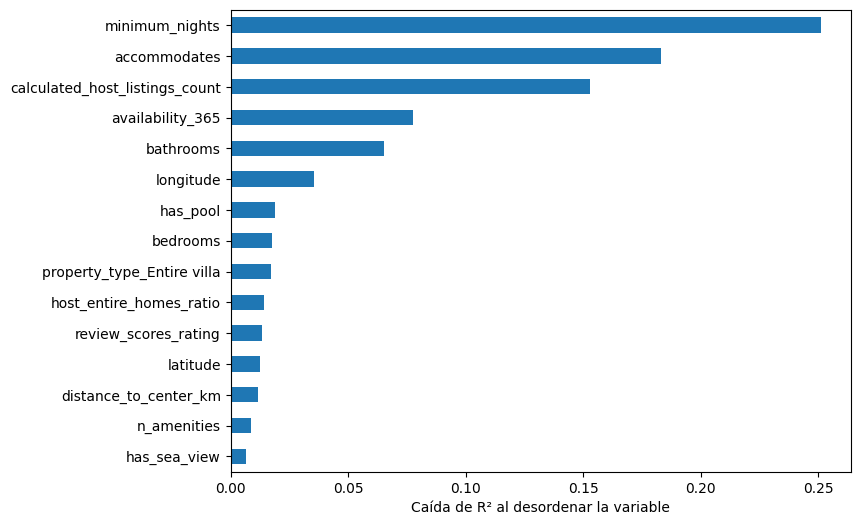

In [21]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Caída de R² al desordenar la variable")

### 10.2 Interpretación

**`minimum_nights` vuelve a dominar** (caída de R² de 0,251), igual que en las otras cinco ciudades, seguido de `accommodates` (0,183) y, en tercer lugar, **`calculated_host_listings_count`** (0,153) — coherente con el hallazgo de `02_feature_engineering.ipynb` de que Mallorca es, con diferencia, el mercado más profesionalizado de las seis ciudades (mediana de 10 anuncios por host). `availability_365` (0,077) y `bathrooms` (0,065) completan el top 5.

**El hallazgo más llamativo**: ningún `district_*` ni `neighbourhood_price_encoded` entra en el top 15 — la primera vez en el proyecto que la geografía "por barrio/distrito" queda completamente fuera. Coherente con la EDA y feature engineering: con 53 municipios y un patrón de precios no relacionado con la centralidad (Palma barata, pueblos exclusivos del interior caros, zonas de turismo masivo también baratas), ninguna columna de distrito por sí sola concentra suficiente señal, y el target encoding se diluye entre las 53 categorías. En su lugar, el modelo recurre a `longitude` (0,036) y `latitude` (0,013) directamente, además de variables de tipo de propiedad como `property_type_Entire villa` (0,017) y `has_pool` (0,019, confirmando la EDA). `distance_to_center_km` (0,012) también entra, pese a su correlación lineal casi nula (sección 8.1 de `02_feature_engineering.ipynb`): un modelo de árboles sí puede aprovechar su relación en forma de "U".

### 10.3 SHAP: cuánto y en qué dirección

Se calcula sobre el test, igual que la importancia por permutación.

In [22]:
explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
shap_values = explainer(X_test)

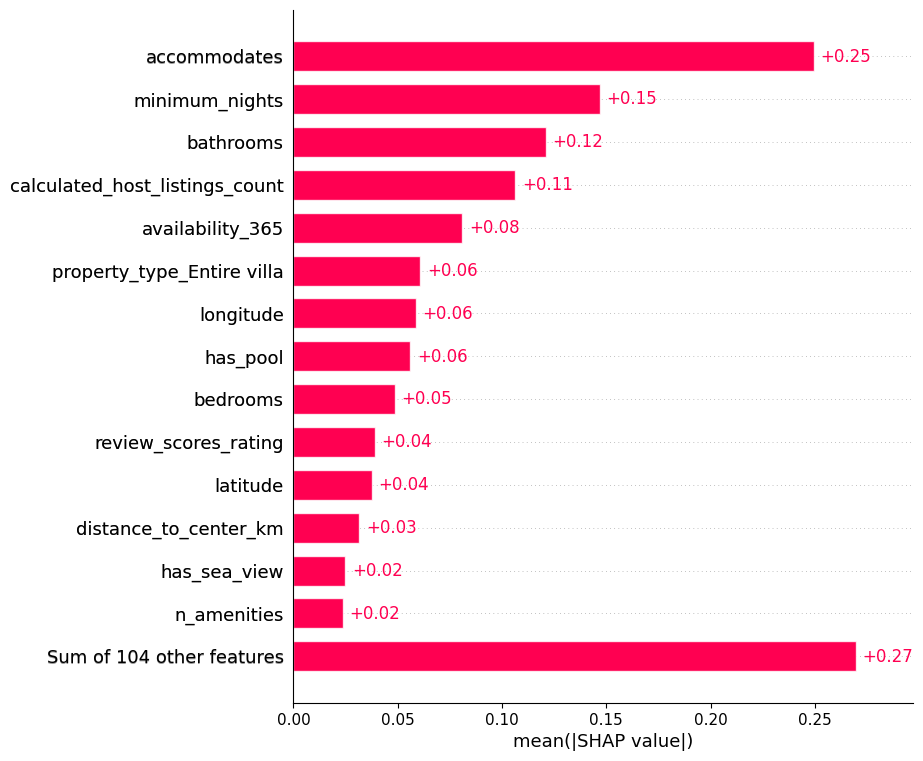

In [23]:
shap.plots.bar(shap_values, max_display=15)

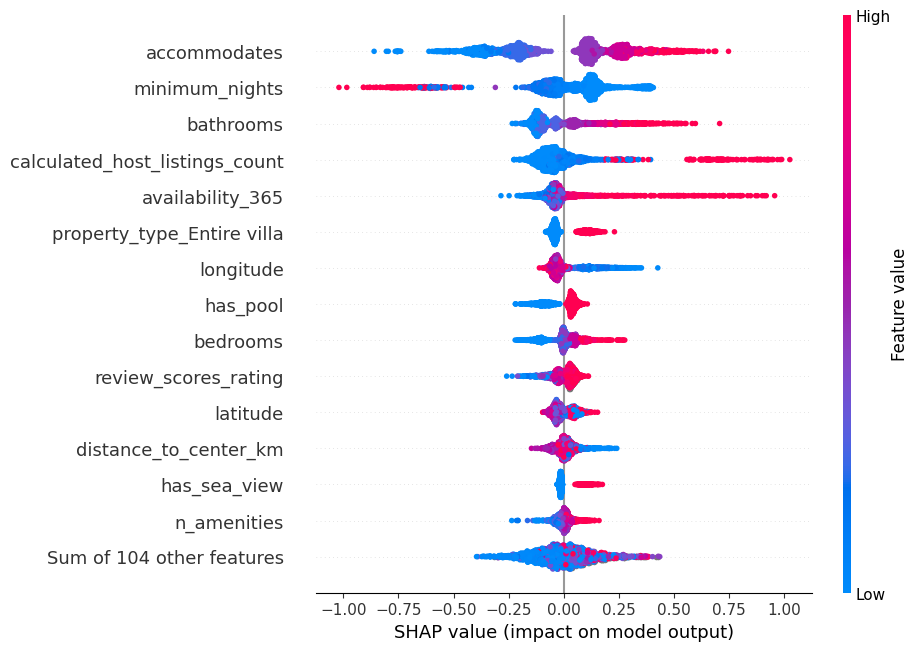

In [24]:
shap.plots.beeswarm(shap_values, max_display=15)

Los mismos métodos coinciden en las variables, con algún cambio de orden — visto en la EDA/feature engineering: `accommodates` sube al primer puesto por SHAP, mientras que `minimum_nights` domina en permutation importance.

In [25]:
sv = pd.DataFrame(shap_values.values, columns=X_test.columns)
mean_abs_shap = sv.abs().mean().sort_values(ascending=False)
mean_abs_shap.head(15)

accommodates                      0.249399
minimum_nights                    0.147060
bathrooms                         0.120957
calculated_host_listings_count    0.106431
availability_365                  0.080955
property_type_Entire villa        0.060794
longitude                         0.058681
has_pool                          0.055951
bedrooms                          0.048539
review_scores_rating              0.039098
latitude                          0.037597
distance_to_center_km             0.031544
has_sea_view                      0.024889
n_amenities                       0.023592
days_since_last_review            0.022526
dtype: float64

SHAP pone a **`accommodates`** en primer lugar (0,249, por delante de `minimum_nights`, 0,147), y **`bathrooms`** sube al tercer puesto (0,121), por delante de `calculated_host_listings_count` (0,106). Ambos métodos coinciden en que el tamaño, la estancia mínima y cuántos anuncios gestiona el host son piezas clave, aunque no en el orden exacto. Igual que en la importancia por permutación, ningún `district_*` ni `neighbourhood_price_encoded` entra en el top 15 de SHAP: la señal geográfica que sí aparece (`longitude`, `latitude`, `distance_to_center_km`) viene de las coordenadas y la distancia, no del municipio codificado.

In [26]:
direction_feats = [
    "accommodates", "minimum_nights", "bathrooms", "calculated_host_listings_count",
    "property_type_Entire villa", "has_pool", "longitude", "latitude",
]
for f in direction_feats:
    corr = X_test[f].astype(float).corr(sv[f])
    print(f"{f}: correlación valor↔SHAP = {corr:.2f}")

accommodates: correlación valor↔SHAP = 0.94
minimum_nights: correlación valor↔SHAP = -0.86
bathrooms: correlación valor↔SHAP = 0.94
calculated_host_listings_count: correlación valor↔SHAP = 0.89
property_type_Entire villa: correlación valor↔SHAP = 0.97
has_pool: correlación valor↔SHAP = 0.94
longitude: correlación valor↔SHAP = -0.77
latitude: correlación valor↔SHAP = 0.17


La dirección es la esperada en la mayoría: `accommodates` (0,94), `bathrooms` (0,94), `calculated_host_listings_count` (0,89), `has_pool` (0,94) y `property_type_Entire villa` (0,97) empujan el precio hacia arriba con fuerza y de forma muy consistente cuando son altos. `minimum_nights` (-0,86) va al revés, el mismo patrón de "alquiler de larga estancia más barato por noche" que en las otras ciudades.

**Un matiz geográfico propio de Mallorca**: `longitude` (-0,77) tiene una relación direccional clara y consistente, pero `latitude` (0,17) apenas la tiene. Tiene sentido a la luz de la forma de la isla (rango de coordenadas visto en la EDA, sección 11.1): de este a oeste hay unos 96,5km, frente a unos 69,7km de norte a sur — moverse en longitud separa mejor las zonas de precio que moverse en latitud, así que el modelo se apoya casi en exclusiva en la coordenada que sí aporta señal.

### 10.4 Un ejemplo concreto

Se elige un anuncio de precio cercano a la mediana del test, y donde además el modelo acierta bastante.

Precio real: 411.00€, predicho: 404.71€


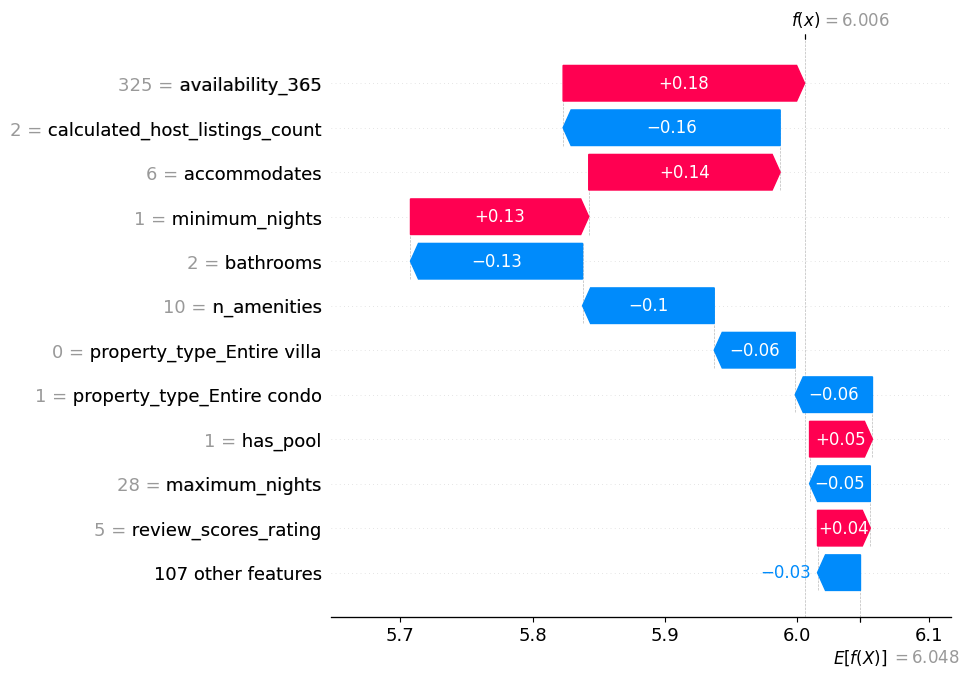

In [27]:
pred_test_all = np.expm1(final_pipeline.predict(X_test))
error_test = pred_test_all - y_test.values
median_price = y_test.median()

candidate_mask = (np.abs(y_test.values - median_price) < 20) & (np.abs(error_test) < 10)
example_pos = np.where(candidate_mask)[0][0]

print(f"Precio real: {y_test.iloc[example_pos]:.2f}€, predicho: {pred_test_all[example_pos]:.2f}€")
shap.plots.waterfall(shap_values[example_pos], max_display=12)

El valor base (`E[f(X)]`) equivale a unos 422€. Para este anuncio en concreto (alojamiento completo para 6 personas, 2 dormitorios, 2 baños, `minimum_nights=1`, disponible 325 días al año, gestionado por un host pequeño con solo 2 anuncios, con piscina): la alta disponibilidad y la estancia mínima de solo 1 noche empujan el precio hacia arriba, mientras que gestionarlo un host tan pequeño y tener "solo" 2 baños para 6 personas lo empujan hacia abajo, hasta llegar a la predicción final de 404,71€ (el precio real era 411€, un acierto casi exacto). El mismo tipo de desglose que en las otras ciudades, con un matiz propio de Mallorca: aquí no aparece ningún `district_*` entre los factores relevantes de este ejemplo, coherente con el hallazgo de la sección 10.2.

## 11. Guardar el modelo

Guardar el modelo final entrenado (con `joblib`) en `models/mallorca/`, para que `05_model_evaluation.ipynb` lo cargue directamente.

### 11.1 El modelo

In [28]:
import joblib

joblib.dump(final_pipeline, f"{PROJECT_DIR}/models/mallorca/price_model.pkl")

['/Users/yagocoll/Documents/Master/Airbnb/models/mallorca/price_model.pkl']

### 11.2 Metadatos

Se guarda todo lo que `05_model_evaluation.ipynb` necesitará saber sin releer este notebook entero.

In [29]:
import json
from datetime import date

metadata = {
    "model": "HistGradientBoostingRegressor",
    "date": str(date.today()),
    "target": target_col,
    "id_cols": id_cols,
    "leakage_cols_excluded": leakage_cols,
    "feature_cols": feature_cols,
    "best_params": {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items()},
    "test_metrics": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
    "baseline_metrics": {"model": "Regresión lineal", "RMSE": 699.54, "MAE": 267.99, "R2": 0.39, "MAPE": 39.64},
}


metadata["test_metrics"]["R2_log"] = float(r2_score(y_test_log, final_pipeline.predict(X_test)))
with open(f"{PROJECT_DIR}/models/mallorca/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'model': 'HistGradientBoostingRegressor',
 'date': '2026-09-09',
 'target': 'price',
 'id_cols': ['id', 'host_id', 'host_profile_id'],
 'leakage_cols_excluded': ['price_log',
  'price_per_accommodate',
  'price_per_min_night'],
 'feature_cols': ['host_is_superhost',
  'host_has_profile_pic',
  'host_identity_verified',
  'latitude',
  'longitude',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'beds',
  'minimum_nights',
  'maximum_nights',
  'availability_365',
  'number_of_reviews',
  'number_of_reviews_ltm',
  'estimated_occupancy_l365d',
  'review_scores_rating',
  'calculated_host_listings_count',
  'reviews_per_month',
  'has_license',
  'number_of_reviews_log',
  'number_of_reviews_ltm_log',
  'reviews_per_month_log',
  'bedrooms_log',
  'beds_log',
  'bathrooms_log',
  'calculated_host_listings_count_log',
  'room_type_Entire home/apt',
  'room_type_Hotel room',
  'room_type_Private room',
  'district_Alaró',
  'district_Alcúdia',
  'district_Algaida',
  'district_Andratx',


`R2_log` (0,78) es el R² calculado sobre `log1p(price)`, la escala en la que el modelo realmente entrena — bastante más alto que el R² en euros (0,54), precisamente porque en euros pesan mucho los precios extremos que se vieron en la sección 8.2 (la villa de 22.260€ del test, entre otras). Está en línea con Málaga (0,78) y bastante por encima de Sevilla (0,60), pese a tener el peor R² en euros de las seis ciudades: el modelo "entiende" el mercado de Mallorca en escala relativa/logarítmica casi tan bien como las ciudades más fáciles, pero la escala absoluta en euros es mucho menos indulgente con los pocos casos extremos. Se guarda como métrica adicional para que la app pueda mostrar una cifra de "cuánto explica el modelo" comparable entre ciudades.

## 12. Conclusiones

Resumen de qué modelo ganó, cuánto mejora sobre el baseline, y qué variables resultaron más importantes.

### El proceso, resumido

1. Se probaron 4 tipos de modelo con hiperparámetros por defecto. Ridge (R²=0,48) ya mejoró notablemente sobre la regresión lineal sin regularizar del baseline (0,39), pero los tres modelos de árboles fueron claramente mejores (0,61-0,64).
2. Se afinaron los tres modelos de árboles. **Hist Gradient Boosting ganó claramente en las cuatro métricas** (0,65 en euros tras el ajuste).
3. El modelo final se evaluó en test una única vez.

### Resultado final

| Modelo | RMSE | MAE | R² | MAPE |
|---|---|---|---|---|
| Regresión lineal (baseline) | 699,54€ | 267,99€ | 0,39 | 39,64% |
| **Hist Gradient Boosting (final)** | **605,94€** | **212,12€** | **0,54** | **30,62%** |

Mejora real y consistente sobre el baseline en las cuatro métricas. El patrón train/test es el "normal" (mejor en train: R²=0,88 frente a 0,54 en test), con una brecha explicada en parte por una cola de precio más pronunciada en el test que en el train (contiene la villa más cara de todo el dataset, 22.260€) y en parte por la combinación de 118 variables, solo 8.835 filas de train y la multicolinealidad más severa de las seis ciudades.

### Qué explica el precio, según el modelo

Permutation importance y SHAP coinciden en que `minimum_nights`, `accommodates`, `bathrooms` y `calculated_host_listings_count` son las variables más importantes, aunque no siempre en el mismo orden. La sorpresa de Mallorca está en la geografía: **ningún `district_*` ni `neighbourhood_price_encoded` entra en el top 15 de ninguno de los dos métodos** — la primera vez en el proyecto que el barrio/distrito queda completamente fuera de la importancia de variables. En su lugar, el modelo se apoya en `longitude` (con una dirección clara) y, en mucha menor medida, `latitude` (con relación mucho más débil, coherente con que la isla se extiende más de este a oeste que de norte a sur), además de `property_type_Entire villa` y `has_pool`, confirmando los hallazgos de la EDA sobre el peso del tipo de propiedad frente a la localización pura.

### Qué queda pendiente

- El análisis de errores más detallado se deja para `05_model_evaluation.ipynb`, que parte de `models/mallorca/price_model.pkl` y `models/mallorca/model_metadata.json` ya guardados aquí.
- Dado el hallazgo de la sección 8.2 (cola de precio más larga en test que en train, con la villa más cara de todo el dataset incluida), sería razonable que `05_model_evaluation.ipynb` revise el error específicamente en los anuncios de precio muy alto, en vez de fiarse solo del R²/RMSE agregado de un único split.
- La redundancia entre `district_*` (53 columnas) y `neighbourhood_price_encoded` (misma columna de origen, sección 5.2 de `02_feature_engineering.ipynb`) no perjudicó al modelo de árboles —de hecho, ninguna de las dos representaciones entró en el top 15 de importancia—, pero sigue siendo un candidato claro a simplificar si en el futuro se quisiera un modelo lineal interpretable para Mallorca.